In [2]:
import numpy as np

class LinearRegressionGD:
    def __init__(self, eta = 0.01, n_iter = 100 , random_state= 1):
      self.eta = eta
      self.n_iter = n_iter
      self.random_state = random_state

    def fit(self , X,y):
      rgen = np.random.RandomState(self.random_state)
      self.w_ = rgen.normal(loc=0.0 , scale = 0.01, size = X.shape[1])
      self.b_ = np.array([0.])

      self.losses_ = []

      for i in range(self.n_iter):
        output = self.net_input(X)
        errors = (y - output)
        self.w_ += self.eta * 2.0 * X.T.dot(errors) / X.shape[0]
        self.b_ += self.eta * 2.0 * errors.mean()
        loss = (errors**2).mean()
        self.losses_.append(loss)
      return self

    def net_input(self, X):
      return np.dot(X, self.w_) + self.b_

    def predict(self, X):
      return self.net_input(X)


In [3]:
from sklearn.datasets import fetch_openml

ames = fetch_openml(name = 'house_prices', as_frame = True)
df = ames.frame
# selecting the desired columns
columns = [
    "OverallQual",
    "OverallCond",
    "GrLivArea",
    "CentralAir",
    "TotalBsmtSF",
    "SalePrice",
]

df_new = df[columns]
print(df_new.head())

   OverallQual  OverallCond  GrLivArea CentralAir  TotalBsmtSF  SalePrice
0            7            5       1710          Y          856     208500
1            6            8       1262          Y         1262     181500
2            7            5       1786          Y          920     223500
3            7            5       1717          Y          756     140000
4            8            5       2198          Y         1145     250000


In [4]:
df_new.shape

df_new['CentralAir'] = df_new['CentralAir'].map({'N': 0, 'Y':1})

df_new['CentralAir'].value_counts()

/tmp/ipykernel_1569/1663945094.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['CentralAir'] = df_new['CentralAir'].map({'N': 0, 'Y':1})


,count
CentralAir,
1,1365
0,95


In [5]:
#checking for the null_values

df_new.isna().sum()

,0
OverallQual,0
OverallCond,0
GrLivArea,0
CentralAir,0
TotalBsmtSF,0
SalePrice,0


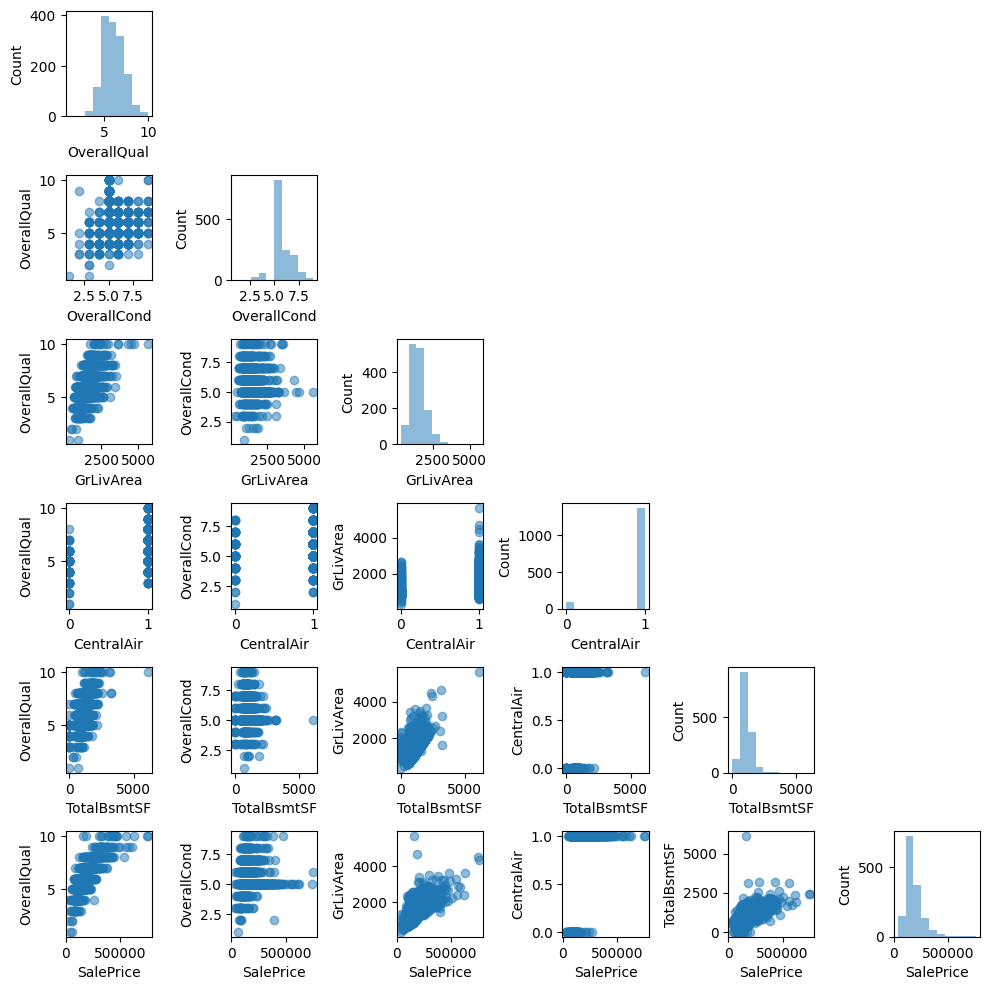

In [6]:
import matplotlib.pyplot as plt
from mlxtend.plotting import scatterplotmatrix

scatterplotmatrix(df_new.values, figsize=(10,10), alpha=0.5,names=df_new.columns)
plt.tight_layout()

plt.show()

Looking at the data using the corelation matrix


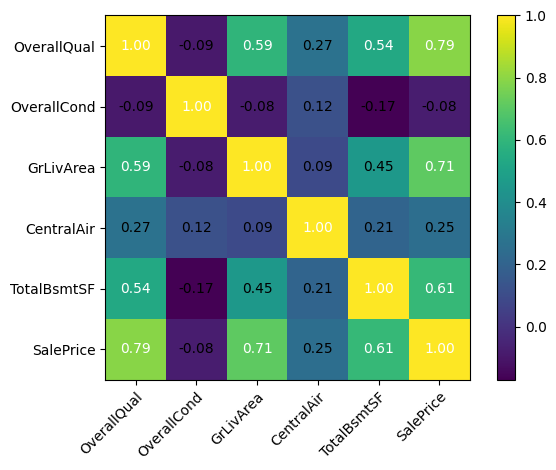

In [7]:
#using the corelation matrix
#usin the numpy np.corrcoef()
from mlxtend.plotting import heatmap

cm = np.corrcoef(df_new.values.T)

hm = heatmap(cm, row_names=df_new.columns, column_names=df_new.columns)
plt.tight_layout()
plt.show()

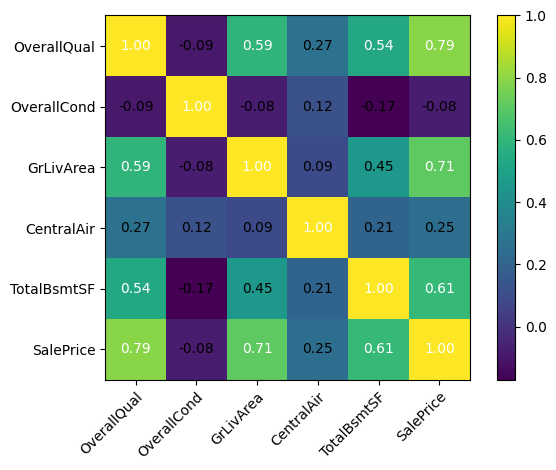

In [8]:
# using the Pandas corr() function
cor = df_new.corr()
ht = heatmap(cor.values, row_names=cor.columns, column_names=cor.columns)
plt.tight_layout()
plt.show()

In [9]:
X = df_new[['GrLivArea']].values
y = df_new['SalePrice'].values

from sklearn.preprocessing import StandardScaler

sc_x = StandardScaler()
sc_y = StandardScaler()

X_std = sc_x.fit_transform(X)
y_std = sc_y.fit_transform(y[: , np.newaxis]).flatten()
lr = LinearRegressionGD(eta = 0.1)
lr.fit(X_std, y_std)



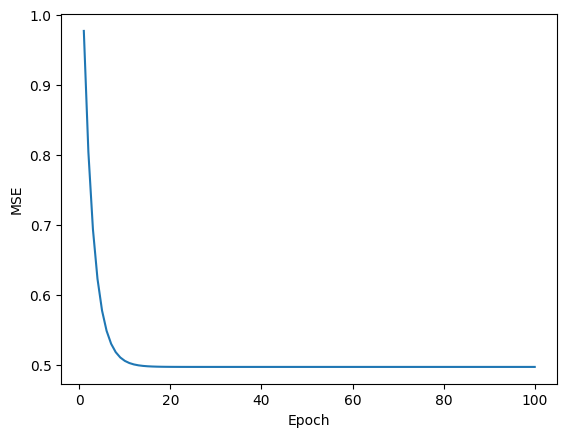

In [10]:
plt.plot(range(1, lr.n_iter +1), lr.losses_)
plt.ylabel('MSE')
plt.xlabel('Epoch')
plt.show()

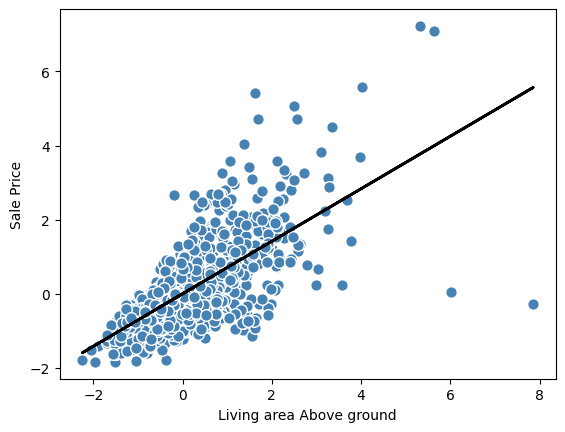

In [11]:
def lin_regplot(X , y, model):
  plt.scatter(X,y , c = "steelblue" , edgecolor ='white' , s = 70)
  plt.plot(X, model.predict(X) , color = 'black' , lw = 2)

#=============================
# Plotting the regression plot
#=============================

lin_regplot(X_std , y_std , lr)
plt.xlabel("Living area Above ground")
plt.ylabel("Sale Price")
plt.show()

In [12]:
# ======================================
# Predicted price back to original price
# ======================================
value = np.array([[2500]])
feature_std = sc_x.transform(value)
target_std = lr.predict(feature_std)
target_reverted = sc_y.inverse_transform(target_std.reshape(-1,1))

# inverse_transform reverse the encoding/scaling that was previously applied to the fit_tranformer

print(f"Sale price : {target_reverted.flatten()[0]:.2f}")

Sale price : 286394.92


In [13]:
df_new['GrLivArea'].head()

,GrLivArea
0,1710
1,1262
2,1786
3,1717
4,2198


In [14]:
# 1. Prinitng the slope and intercept
print(f"slope : {lr.w_[0]:.3f}")

print(f"intercept : {lr.b_[0]:.3f}")

slope : 0.709
intercept : 0.000


In [15]:
# 1. using the unscaled data and Scikit lib to crate a Linear regression model

from sklearn.linear_model import LinearRegression

slr = LinearRegression()

slr.fit(X, y)
y_pred = slr.predict(X)

print(f"Slope : {slr.coef_[0]:.3f}")
print(f"Intercept : {slr.intercept_:.3f}")


Slope : 107.130
Intercept : 18569.026


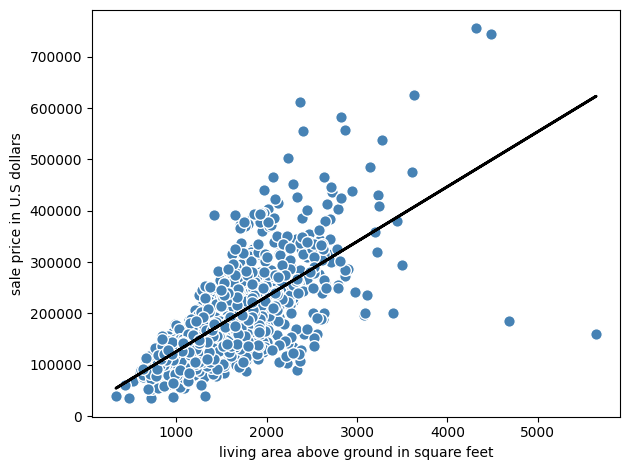

In [16]:
lin_regplot(X, y , slr)
plt.xlabel("living area above ground in square feet")
plt.ylabel("sale price in U.S dollars")
plt.tight_layout()
plt.show()

## **Fitting a Robust regression model using RANSAC**

RANdom SAmple Consenus(RANSAC) Algorithm --> it fits the data to a subset of data (inliners)

In [17]:
from sklearn.linear_model import RANSACRegressor

# 1. Setting up the RANSAC algorith
ransac = RANSACRegressor(LinearRegression(),
                         max_trials = 100, # default
                         min_samples= 0.95,
                         residual_threshold = 50000, # Default value
                         random_state = 123)
ransac.fit(X , y)

RANSACRegressor(estimator=LinearRegression(), min_samples=0.95,
                random_state=123, residual_threshold=50000)

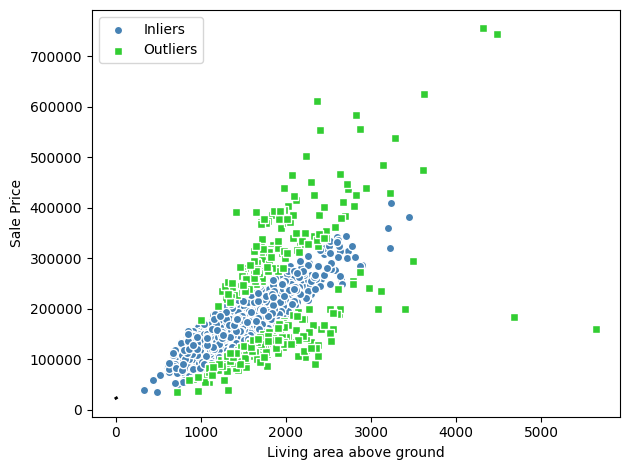

In [18]:
inlier_mask = ransac.inlier_mask_
outlier_mask = np.logical_not(inlier_mask)

line_X = np.arange(3, 10, 1)
line_y_ransac = ransac.predict(line_X[:, np.newaxis])
plt.scatter(X[inlier_mask], y[inlier_mask],
            c = 'steelblue', edgecolor='white',
            marker='o', label='Inliers')
plt.scatter(X[outlier_mask], y[outlier_mask],
            c = 'limegreen', edgecolor='white',
            marker='s', label='Outliers')

plt.plot(line_X,line_y_ransac, color = 'black', lw = 2)
plt.xlabel("Living area above ground")
plt.ylabel("Sale Price")
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [19]:
print(f'Slope ; {ransac.estimator_.coef_[0]:.3f}')
print(f'Intercept : {ransac.estimator_.intercept_:.3f}')


Slope ; 102.996
Intercept : 22787.831


In [20]:
def mean_absolute_deviation(data):
  return f"{np.mean(np.abs(data - np.mean(data))):.3f}"

mean_absolute_deviation(y)

'57434.770'

# **Evaluating the Performance of the LinearRegression Model**

### Saperating the dataset into test and train to evaluate the model performance

In [22]:
# 1. evaluating the Model performance

from sklearn.model_selection import train_test_split

# 2. creating the target and features

target = 'SalePrice'
features = df_new.columns[df_new.columns  != target]  # this will select All columns expect target == SalePrice

X = df_new[features].values
y = df_new[target].values

# 3. splitting the data into train_test

X_train , X_test , y_train , y_test = train_test_split(X , y ,
                                                       test_size = 0.3 ,
                                                       random_state = 123)

simple_lr = LinearRegression()
simple_lr.fit(X_train , y_train)
y_pred_train = simple_lr.predict(X_train)
y_pred_test = simple_lr.predict(X_test)


In [23]:
# 1. Looking for the MSE

from sklearn.metrics import mean_squared_error

mse_train = mean_squared_error(y_train , y_pred_train)
mse_test = mean_squared_error(y_test , y_pred_test)

print(f"MSE train : {mse_train:.3f}")
print(f"MSE test : {mse_test:.3f}")

MSE train : 1755382580.216
MSE test : 1292817653.085


In [24]:
#1. lokking for MAE

from sklearn.metrics import mean_absolute_error

mae_train = mean_absolute_error(y_train , y_pred_train)
mae_test = mean_absolute_error(y_test , y_pred_test)

print(f"MAE train : {mae_train:.3f}")
print(f"MAE test : {mae_test:.3f}")

MAE train : 26471.083
MAE test : 24259.417


In [25]:
# 1. looking for the r2_score

from sklearn.metrics import r2_score

r2_train = r2_score(y_train , y_pred_train)
r2_test = r2_score(y_test , y_pred_test)

print(f"R2 train : {r2_train:.3f}")
print(f"R2 test : {r2_test:.3f}")

R2 train : 0.732
R2 test : 0.775


r2_score is basically, telling that it can explain the variance of the data 0.90 mean model can make perfect sense of the 90% of the data

| R²      | Simple meaning                                        |
| ------- | ----------------------------------------------------- |
| **1.0** | Model explains everything perfectly                   |
| **0.9** | Model explains ~90% of the variation → very good      |
| **0.7** | Model explains ~70% → reasonably good                 |
| **0.4** | Model explains ~40% → not very strong                 |
| **0**   | Model isn't better than simply predicting the average |
| **< 0** | Model is worse than predicting the average            |
